<img src = "https://drive.google.com/uc?export=view&id=1VV2e_u46fNm_ewns8QW2HGRZAPHh-e2t" alt = "Encabezado MLDS" width = "100%">  </img>

# **Diseño e implementación experimental**
---

Este notebook es una plantilla que le puede servir como guía para el tercer entregable del proyecto aplicado.

## **0. Cargar el Conjunto de Datos y Padding de las Imagenes**

In [1]:
import tarfile
import nibabel as nib
import matplotlib.pyplot as plt
import cv2
import os

!curl -L "https://drive.google.com/uc?export=download&id=1RzPB1_bqzQhlWvU-YGvZzhx2omcDh38C" -o "Task04_Hippocampus.tar"
!tar -xf Task04_Hippocampus.tar

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 27.1M  100 27.1M    0     0  3209k      0  0:00:08  0:00:08 --:--:-- 6979k


In [3]:
import torch, numpy as np
import re

ROOT = "/content/Task04_Hippocampus"
IMG_DIR, LBL_DIR = os.path.join(ROOT, "imagesTr"), os.path.join(ROOT, "labelsTr")
OUT_IMG, OUT_LBL = os.path.join(ROOT, "imagesTr_pad"), os.path.join(ROOT, "labelsTr_pad")
os.makedirs(OUT_IMG, exist_ok=True); os.makedirs(OUT_LBL, exist_ok=True)

def valid_list(p):
    return sorted([f for f in os.listdir(p) if f.endswith((".nii",".nii.gz")) and not f.startswith("._")])

def bname(fn):
    return re.sub(r'\.nii(\.gz)?$', '', fn)

imgs = valid_list(IMG_DIR); lbls = valid_list(LBL_DIR)
imgs_map = {bname(f): f for f in imgs}; lbls_map = {bname(f): f for f in lbls}
common = sorted(set(imgs_map) & set(lbls_map))

assert common, "No hay pares imagen–máscara."

maxX = maxY = maxZ = 0
for k in common:
    si = nib.load(os.path.join(IMG_DIR, imgs_map[k])).shape
    sl = nib.load(os.path.join(LBL_DIR, lbls_map[k])).shape
    assert si == sl, f"Shape distinto en {k}: {si} vs {sl}"
    maxX, maxY, maxZ = max(maxX, si[0]), max(maxY, si[1]), max(maxZ, si[2])
TARGET = (maxX, maxY, maxZ)
print("TARGET shape:", TARGET)

def pad_center(arr, target):
    pad = []
    for s, t in zip(arr.shape, target):
        total = max(t - s, 0)
        left = total // 2
        right = total - left
        pad.append((left, right))
    return np.pad(arr, pad_width=pad, mode="constant", constant_values=0)

n_ok = 0
for k in common:
    ip = os.path.join(IMG_DIR, imgs_map[k])
    img_nii = nib.load(ip)
    img = np.asanyarray(img_nii.dataobj)
    img_pad = pad_center(img, TARGET).astype(np.float32)
    lp = os.path.join(LBL_DIR, lbls_map[k])
    lbl_nii = nib.load(lp)
    lbl = np.asanyarray(lbl_nii.dataobj)
    lbl_pad = pad_center(lbl, TARGET).astype(np.int16)

    nib.save(nib.Nifti1Image(img_pad, img_nii.affine), os.path.join(OUT_IMG, imgs_map[k]))
    nib.save(nib.Nifti1Image(lbl_pad, lbl_nii.affine), os.path.join(OUT_LBL, lbls_map[k]))
    n_ok += 1

print(f"{n_ok} pares padded → {OUT_IMG} / {OUT_LBL}")



print("== VERIFICACION ==")

ROOT = "/content/Task04_Hippocampus"
IMG_PAD, LBL_PAD = os.path.join(ROOT, "imagesTr_pad"), os.path.join(ROOT, "labelsTr_pad")
TARGET = (43, 59, 47)

bad = []
for f in sorted(os.listdir(IMG_PAD)):
    if not f.endswith((".nii",".nii.gz")):
      continue

    ip, lp = os.path.join(IMG_PAD,f), os.path.join(LBL_PAD,f)
    si, sl = nib.load(ip).shape, nib.load(lp).shape
    if si != TARGET or sl != TARGET or si != sl:
        bad.append((f, si, sl))
print("Inconsistencias:", bad if bad else "Ninguna")
vals = set()
for f in sorted(os.listdir(LBL_PAD)):
    if not f.endswith((".nii",".nii.gz")):
      continue
    arr = np.asanyarray(nib.load(os.path.join(LBL_PAD,f)).dataobj)
    vals.update(np.unique(arr).tolist())

print("Valores únicos en masks (global):", sorted(vals))

TARGET shape: (43, 59, 47)
260 pares padded → /content/Task04_Hippocampus/imagesTr_pad / /content/Task04_Hippocampus/labelsTr_pad
== VERIFICACION ==
Inconsistencias: Ninguna
Valores únicos en masks (global): [0, 1, 2]


## **1. Particion del conjunto de datos**
---

Si el dataset no tiene por defecto definida una partición en conjuntos de entrenamiento y prueba, hágala usted, en las proporciones que considere oportunas.

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path

ROOT = Path("/content/Task04_Hippocampus")
IMAGES_DIR = ROOT / "imagesTr_pad"
LABELS_DIR = ROOT / "labelsTr_pad"

assert IMAGES_DIR.exists(), f"No existe {IMAGES_DIR}"
assert LABELS_DIR.exists(), f"No existe {LABELS_DIR}"

def _stem_no_ext(p: Path):
    s = p.name
    if s.endswith(".nii.gz"):
        return s[:-7]
    return s[:s.rfind(".")] if "." in s else s

img_files = sorted([p for p in IMAGES_DIR.glob("*.nii*")])
msk_files = sorted([p for p in LABELS_DIR.glob("*.nii*")])
msk_map = {_stem_no_ext(p): p for p in msk_files}

pairs = []
for ip in img_files:
    k = _stem_no_ext(ip)
    if k in msk_map:
        pairs.append((ip, msk_map[k]))
    else:
        raise FileNotFoundError(f"No se encontró máscara para {ip.name}")

print(f"Pares encontrados: {len(pairs)}")


def minmax_normalize(img: np.ndarray, clip=None, eps=1e-6):
    """
    img: np.ndarray (D,H,W)
    clip: None o tupla (p_low, p_high) en percentiles, e.g., (1, 99)
    Retorna img en [0,1]
    """
    x = img.astype(np.float32)
    if clip is not None:
        lo, hi = np.percentile(x, clip)
        if hi - lo < eps:
            lo, hi = x.min(), x.max()
        x = np.clip(x, lo, hi)

    minv = float(x.min())
    maxv = float(x.max())
    if maxv - minv < eps:
        return np.zeros_like(x, dtype=np.float32)
    return (x - minv) / (maxv - minv)


### Data Loaders ####
class Hippocampus3DDataset(Dataset):
    def __init__(self, pairs, norm='minmax', clip=(1, 99), dtype_img=np.float32):
        """
        norm: 'minmax' (default) o None
        clip: percentiles para recorte robusto antes del min-max; usa None para desactivar
        """
        self.pairs = pairs
        self.norm = norm
        self.clip = clip
        self.dtype_img = dtype_img

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        img_nii = nib.load(str(img_path))
        msk_nii = nib.load(str(msk_path))
        img = nib.as_closest_canonical(img_nii).get_fdata().astype(self.dtype_img)
        msk = nib.as_closest_canonical(msk_nii).get_fdata().astype(np.int16)

        if img.shape != msk.shape:
            raise ValueError(f"Shape mismatch {img.shape} vs {msk.shape} en {img_path.name}")

        if self.norm == 'minmax':
            img = minmax_normalize(img, clip=self.clip)
        elif self.norm is None:
            img = img.astype(np.float32)
        else:
            raise ValueError(f"norm '{self.norm}' no soportada. Usa 'minmax' o None.")

        img = torch.from_numpy(img[None, ...]).float()
        msk = torch.from_numpy(msk).long()
        return img, msk

SEED = 9
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=SEED, shuffle=True)

train_ds = Hippocampus3DDataset(train_pairs, norm='minmax', clip=(1, 99))
val_ds  = Hippocampus3DDataset(val_pairs, norm='minmax', clip=(1, 99))

BATCH_SIZE = 2
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

xb, yb = next(iter(train_loader))
print("Batch imagen:", tuple(xb.shape))
print("Batch máscara:", tuple(yb.shape))
print("Rango img [min,max]:", float(xb.min()), float(xb.max()))

Pares encontrados: 260
Batch imagen: (2, 1, 43, 59, 47)
Batch máscara: (2, 43, 59, 47)
Rango img [min,max]: 0.0 1.0


In [6]:

print(f"Imágenes en train_ds: {len(train_ds)}")
print(f"Imágenes en val_ds:   {len(val_ds)}")

print(f"Batches en train_loader: {len(train_loader)}")
print(f"Batches en val_loader:   {len(val_loader)}")

Imágenes en train_ds: 208
Imágenes en val_ds:   52
Batches en train_loader: 104
Batches en val_loader:   26


In [7]:
n_train = len(train_ds)
n_val   = len(val_ds)
n_total = n_train + n_val

print("=== Dataset Split ===")
print(f"Total imágenes:     {n_total}")
print(f"Train imágenes (80%): {n_train}")
print(f"Val imágenes (20%):   {n_val}")
print(f"Tamaño de batch:    {BATCH_SIZE}")
print(f"Batches por epoch -> Train: {len(train_loader)}, Val: {len(val_loader)}")

=== Dataset Split ===
Total imágenes:     260
Train imágenes (80%): 208
Val imágenes (20%):   52
Tamaño de batch:    2
Batches por epoch -> Train: 104, Val: 26


### Normalización Min–Max y verificación de `DataLoader`

Se implementó una normalización **Min–Max** por volumen para las imágenes 3D del conjunto *Task04_Hippocampus*, reescalando las intensidades al rango **[0, 1]**.  
Antes del escalado, se aplicó un **recorte robusto por percentiles (1 – 99)** para eliminar valores atípicos extremos.  
Esto mejora la estabilidad del entrenamiento en redes tipo **UNet 3D**, evitando saturaciones o gradientes inestables.

Además, se añadió una dimensión de canal extra `(1, D, H, W)` a cada imagen (de modo que el modelo reciba tensores 4D con canal explícito).  
Las máscaras mantienen su forma `(D, H, W)` y etiquetas `{0, 1, 2}`.

Todo quedó balanceado, sin inconsistencias en shapes y con intensidades normalizadas adecuadamente para entrenar una UNet 3D.

## **2. Selección y diseño de modelos**
---

Seleccione el/los modelo/s a explorar para aplicar sobre el conjunto de datos. Recuerde, la selección del modelo está influenciada por diferentes factores. Si el problema es de análisis de imagen, muy seguramente hay que explorar diversas redes neuronales convolucionales. Si el problema está relacionado con NLP, muy seguramente hay que explorar modelos basados en Tranformers.

Además, debe definir cuál es su problema:

- **Regresión**: se busca estimar un valor continúo a partir de los datos.
- **Clasificación**: permite estimar un valor categórico a partir de los datos.
- **Agrupamiento**: permite encontrar grupos de datos similares.
- **Otros modelos**: recuerde que dispone de otros tipos de tareas supervisadas y no supervisadas.

En cualquier caso los profundos disponibles en _TensorFlow_ constituyen una base sobre la que usted debe definir un clasificador/regresor/_encoder_/_decoder_ final, compuesto de una o más capas densas, con opción de incluir _dropout_ o capas de normalización.

Justifique la escogencia y diseño de los modelos a explorar:

En este proyecto abordamos una **tarea de segmentación semántica tridimensional**, donde el objetivo es clasificar cada vóxel del volumen médico (imagen 3D) en diferentes clases anatómicas. En este caso, trabajamos con el conjunto de datos **Task04_Hippocampus** del *Medical Segmentation Decathlon*, el cual contiene estructuras cerebrales (hipocampo) con etiquetas `{0, 1, 2}` que representan fondo y regiones anatómicas específicas.

Dado que el problema implica **análisis de imágenes volumétricas (3D)** y requiere identificar patrones espaciales complejos, se implementará una **red neuronal convolucional 3D (CNN)**, específicamente una **U-Net 3D**, modelo ampliamente utilizado en tareas médicas por su capacidad de combinar información local y contextual mediante un esquema de codificación–decodificación con *skip connections*.

- **Tipo de problema:** Clasificación voxel a voxel → Segmentación semántica 3D.  
- **Modelo seleccionado:** **U-Net 3D** implementada en *PyTorch*.  
- **Justificación:**  
  - La U-Net 3D permite preservar información espacial fina gracias a sus conexiones de salto.  
  - Es robusta frente a tamaños de entrada variables y eficiente en contextos médicos donde los datos son limitados.  
  - Su arquitectura encoder–decoder facilita una reconstrucción precisa de las estructuras anatómicas.  
  - El uso de convoluciones 3D capta relaciones espaciales en las tres dimensiones (x, y, z), esenciales para una segmentación coherente del volumen.

El modelo incluirá capas de **Batch Normalization** y **Dropout** para mejorar la estabilidad del entrenamiento y prevenir sobreajuste.  
Posteriormente, se evaluará mediante métricas como **Dice Score** y **IoU (Intersection over Union)**, apropiadas para tareas de segmentación.

En síntesis, se explorará un modelo **U-Net 3D** para segmentar estructuras cerebrales en volúmenes médicos, optimizado para captar tanto los detalles locales como la morfología global del hipocampo.

## **3. Implementación de los modelos**
---

Implemente los modelos descritos anteriormente usando herramientas de _TensorFlow_. Recuerde que puede aplicar técnicas de aumentación de datos, si es necesario.

In [10]:
import torch.nn as nn
import torch.nn.functional as F


############## U-NET3D UTILS #################

class ConvRelu3d(nn.Module):
    """
    Conv3d (+ norm opcional) + ReLU.
    - in_c/out_c: canales
    - k/s/p: kernel/stride/padding (por defecto "same-like": k=3, p=1)
    - norm: None | 'bn' | 'in'  (BatchNorm3d o InstanceNorm3d)
    """
    def __init__(self, in_c, out_c, k=3, s=1, p=1, bias=True, norm='in', act='relu'):
        super().__init__()
        layers = [nn.Conv3d(in_c, out_c, kernel_size=k, stride=s, padding=p, bias=bias)]
        if norm == 'bn':
            layers.append(nn.BatchNorm3d(out_c))
        elif norm == 'in':
            layers.append(nn.InstanceNorm3d(out_c, affine=True))
        if act == 'relu':
            layers.append(nn.ReLU(inplace=True))
        elif act == 'leaky_relu':
            layers.append(nn.LeakyReLU(0.01, inplace=True))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


class MaxPool3d(nn.Module):
    """
    Capa de MaxPooling 3D
    Reduce la resolución espacial y de profundidad del volumen (D, H, W)
    manteniendo la dimensionalidad del canal.
    """
    def __init__(self, k=2, s=2, p=0):
        super().__init__()
        self.net = nn.MaxPool3d(kernel_size=k, stride=s, padding=p)

    def forward(self, x):
        return self.net(x)


class UpConv3d(nn.Module):
    """
    Capa de upsampling mediante transposed convolution 3D.
    - in_c: canales de entrada (nivel profundo)
    - out_c: canales de salida tras la up-conv
    - k, s, p: kernel, stride, padding (por defecto 2x2x2, stride=2)
    """
    def __init__(self, in_c, out_c, k=2, s=2, p=0):
        super().__init__()
        self.net = nn.ConvTranspose3d(in_c, out_c, kernel_size=k, stride=s, padding=p)

    def forward(self, x):
        return self.net(x)


############# ENCODER ##################

class UnetEncoderLayer3d(nn.Module):
    """
    Bloque encoder de U-Net 3D:
    El Forward es: Conv3d -> Conv3d -> (Dropout opcional) -> MaxPool3d
    Retorna: x_down (para el siguiente nivel) y skip (para concatenar en el decoder).
    """
    def __init__(self, in_c, out_c, norm='in', dropout=0.0, use_pool=True):
        super().__init__()
        self.conv1 = ConvRelu3d(in_c,  out_c, norm=norm)
        self.conv2 = ConvRelu3d(out_c, out_c, norm=norm)
        self.dropout = nn.Dropout3d(dropout) if dropout and dropout > 0 else nn.Identity()
        self.pool = MaxPool3d(k=2, s=2) if use_pool else nn.Identity()

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        skip = x          # guardar para skip-connection
        x = self.dropout(x)
        x = self.pool(x)
        return x, skip


############# DECODER ##################

def _match_spatial_3d(x, ref):
    """
    Ajusta x para que tenga el mismo (D,H,W) que ref.
    - Si x es más grande: recorta centrado.
    - Si x es más pequeño: pad centrado (reflect/constant).
    """
    _, _, D, H, W = x.shape
    _, _, Dr, Hr, Wr = ref.shape

    dD, dH, dW = D - Dr, H - Hr, W - Wr

    if dD > 0:
        s = dD // 2
        x = x[:, :, s:D - (dD - s), :, :]
        D = x.shape[2]
    if dH > 0:
        s = dH // 2
        x = x[:, :, :, s:H - (dH - s), :]
        H = x.shape[3]
    if dW > 0:
        s = dW // 2
        x = x[:, :, :, :, s:W - (dW - s)]

    pads = []
    dW = Wr - x.shape[4]
    dH = Hr - x.shape[3]
    dD = Dr - x.shape[2]

    for d in (dW, dH, dD):
        if d > 0:
            left = d // 2
            right = d - left
            pads.extend([left, right])
        else:
            pads.extend([0, 0])

    if any(p > 0 for p in pads):
        x = F.pad(x, (pads[0], pads[1], pads[2], pads[3], pads[4], pads[5]))
    return x


class UnetDecoderLayer3d(nn.Module):
    """
    UpConv3d (duplica D,H,W) -> Concat con skip -> Conv3d+ReLU -> Conv3d+ReLU
    Args:
        in_c : canales que entran desde el nivel más profundo del decoder
        skip_c : canales del skip correspondiente del encoder
        out_c  : canales deseados a la salida del bloque
        norm : 'in' (InstanceNorm3d), 'bn' (BatchNorm3d) o None
        dropout: tasa de Dropout3d (opcional)
    """
    def __init__(self, in_c, skip_c, out_c, norm='in', dropout=0.0):
        super().__init__()
        self.up    = UpConv3d(in_c, out_c, k=2, s=2, p=0)
        self.conv1 = ConvRelu3d(out_c + skip_c, out_c, norm=norm)
        self.conv2 = ConvRelu3d(out_c, out_c, norm=norm)
        self.dropout = nn.Dropout3d(dropout) if dropout and dropout > 0 else nn.Identity()

    def forward(self, x, skip):
        x = self.up(x)

        # Alinear espacialmente con el skip
        x = _match_spatial_3d(x, skip)

        # Concat en canales y doble conv
        x = torch.cat([skip, x], dim=1)
        x = self.conv1(x)
        x = self.dropout(x)
        x = self.conv2(x)
        return x



############# U-Net3d Model ############

class UNet3D(nn.Module):
    def __init__(self, in_channels=1, num_classes=3, base=32, norm='in', dropout=0.0):
        super().__init__()
        C = base

        #  Encoder
        self.enc = nn.ModuleList([
            UnetEncoderLayer3d(in_channels, C,   norm=norm, dropout=dropout),  # 1  ->  C  (skip1) D,H,W
            UnetEncoderLayer3d(C, 2*C,  norm=norm, dropout=dropout),  # C  ->  2C
            UnetEncoderLayer3d(2*C,4*C,  norm=norm, dropout=dropout),  # 2C ->  4C
            UnetEncoderLayer3d(4*C, 8*C,  norm=norm, dropout=dropout),  # 4C ->  8C
        ])

        # Bottleneck
        self.bottleneck = nn.Sequential(
            ConvRelu3d(8*C,16*C, norm=norm),   # 8C  -> 16C
            ConvRelu3d(16*C, 16*C, norm=norm),  # 16C -> 16C
        )

        #  Decoder
        self.dec = nn.ModuleList([
            UnetDecoderLayer3d(16*C,8*C, 8*C,  norm=norm, dropout=dropout),
            UnetDecoderLayer3d(8*C, 4*C, 4*C,  norm=norm, dropout=dropout),
            UnetDecoderLayer3d(4*C, 2*C, 2*C,  norm=norm, dropout=dropout),
            UnetDecoderLayer3d(2*C, C, C,    norm=norm, dropout=dropout), ])

        #  Cabeza de salida
        self.out_conv = nn.Conv3d(C, num_classes, kernel_size=1)

    def forward(self, x):
        skips = []
        # Encoder
        for layer in self.enc:
            x, skip = layer(x)
            skips.append(skip)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        for layer, skip in zip(self.dec, reversed(skips)):
            x = layer(x, skip)

        logits = self.out_conv(x)
        return logits



### Construcción del modelo U-Net 3D

Para abordar la tarea de **segmentación volumétrica** (3D), implementamos desde cero una arquitectura **U-Net 3D** modular y extensible en PyTorch.  
El diseño replica la estructura encoder–decoder con *skip connections*, pero adaptando todas las operaciones convolucionales, normalizaciones y *upsampling* al espacio tridimensional.

---

#### Bloques base

1. **`ConvRelu3d`**
   - Aplica `Conv3d → (InstanceNorm3d o BatchNorm3d) → ReLU`.
   - Captura patrones espaciales en volúmenes tridimensionales.
   - Usa inicialización de He (Kaiming) para estabilidad del gradiente.

2. **`MaxPool3d`**
   - Reduce las tres dimensiones espaciales `(D, H, W)` a la mitad.
   - Permite aumentar el campo receptivo del modelo.

3. **`UpConv3d`**
   - Aplica una `ConvTranspose3d` que duplica las dimensiones espaciales.
   - Permite reconstruir la resolución original en el *decoder*.

---

#### Encoder y Decoder

4. **`UnetEncoderLayer3d`**
   - Realiza dos convoluciones 3D consecutivas (`ConvRelu3d → ConvRelu3d`) seguidas de *pooling*.
   - Devuelve dos salidas:  
     - `x_down`: volumen reducido para el siguiente nivel.  
     - `skip`: copia de alta resolución para las *skip connections*.

5. **`UnetDecoderLayer3d`**
   - Realiza `UpConv3d` → concatenación con el *skip* correspondiente → doble conv.
   - Incluye una función de *center-crop/padding* para alinear dimensiones impares.
   - Recupera la información espacial perdida en el encoder.

---

#### Modelo final: `UNet3D`

La clase principal organiza todos los módulos anteriores:

- **Encoder:** 4 niveles de profundidad con canales crecientes (`base`, `2×`, `4×`, `8×`).
- **Bottleneck:** doble conv 3D para el nivel más profundo.
- **Decoder:** 4 bloques simétricos con `UpConv3d` + concatenación + doble conv.
- **Cabeza de salida:** `Conv3d(1×1×1)` para mapear a `num_classes` (p. ej., `{0,1,2}`).

---

#### Forma del flujo de datos:

Entrada: (B, 1, 43, 59, 47)

↓

Encoder: extracción jerárquica de características 3D

↓

Bottleneck: representación compacta del volumen

↓

Decoder: reconstrucción espacial con skip connections

↓

Salida: (B, num_classes, 43, 59, 47)

#### Detalles de diseño
- Se usó **InstanceNorm3d** por estabilidad con *batch size* pequeño.
- `Dropout3d` opcional para regularización.
- La salida son **logits** sin `softmax`, adecuados para `CrossEntropyLoss`.
- Estructura flexible para modificar profundidad o número de filtros base.

En conjunto, esta implementación de **U-Net 3D** permite procesar volúmenes médicos completos (como el hipocampo) preservando coherencia espacial y capturando relaciones volumétricas complejas.

## Diff Augment

In [32]:
import math

def _affine_grid_3d(theta: torch.Tensor, size):
    """
    theta: (B, 3, 4)  |  size: (B, C, D, H, W)
    """
    B, C, D, H, W = size
    return F.affine_grid(theta, size=(B, C, D, H, W), align_corners=False)

def _apply_grid_sample_3d(x: torch.Tensor, grid: torch.Tensor, mode='bilinear'):
    return F.grid_sample(x, grid, mode=mode, padding_mode='border', align_corners=False)

def rand_brightness_contrast_3d(x, p=0.5, b_range=(-0.1, 0.1), c_range=(0.9, 1.1)):
    if torch.rand(1).item() < p:
        b = torch.empty(x.size(0), 1, 1, 1, 1, device=x.device).uniform_(*b_range)
        c = torch.empty(x.size(0), 1, 1, 1, 1, device=x.device).uniform_(*c_range)
        x = x * c + b
    return x.clamp_(0, 1)

def rand_gamma_3d(x, p=0.5, gamma_range=(0.8, 1.25), eps=1e-6):
    if torch.rand(1).item() < p:
        g = torch.empty(x.size(0), 1, 1, 1, 1, device=x.device).uniform_(*gamma_range)
        x = torch.clamp(x, 0, 1)
        x = torch.pow(x + eps, g)
    return x.clamp_(0, 1)

def rand_gauss_noise_3d(x, p=0.3, sigma=(0.0, 0.02)):
    if torch.rand(1).item() < p:
        std = torch.empty(x.size(0), 1, 1, 1, 1, device=x.device).uniform_(*sigma)
        noise = torch.randn_like(x) * std
        x = x + noise
    return x.clamp_(0, 1)

def rand_flip_3d(x, y, p=0.5):

    if torch.rand(1).item() < p:
        if torch.rand(1).item() < 0.33:
            x = torch.flip(x, dims=[2]); y = torch.flip(y, dims=[1])
        if torch.rand(1).item() < 0.33:
            x = torch.flip(x, dims=[3]); y = torch.flip(y, dims=[2])
        if torch.rand(1).item() < 0.33:
            x = torch.flip(x, dims=[4]); y = torch.flip(y, dims=[3])
    return x, y

def rand_affine_small_3d(x, y, p=0.35, max_rot=10, max_trans=0.05, max_scale=0.10):
    """
    Pequeñas rotaciones (±max_rot grados), traslaciones (±max_trans del tamaño),
    y escalamiento (±max_scale). Usa grid_sample bilinear para img y nearest para mask.
    """
    if torch.rand(1).item() >= p:
        return x, y

    B, C, D, H, W = x.shape
    device = x.device

    rot_x = (torch.rand(B, device=device) * 2 - 1) * math.radians(max_rot)
    rot_y = (torch.rand(B, device=device) * 2 - 1) * math.radians(max_rot)
    rot_z = (torch.rand(B, device=device) * 2 - 1) * math.radians(max_rot)
    scale = 1.0 + (torch.rand(B, device=device) * 2 - 1) * max_scale
    tx = (torch.rand(B, device=device) * 2 - 1) * max_trans
    ty = (torch.rand(B, device=device) * 2 - 1) * max_trans
    tz = (torch.rand(B, device=device) * 2 - 1) * max_trans

    thetas = []
    for b in range(B):
        sx = sy = sz = scale[b]
        cx, cy, cz = torch.cos(rot_x[b]), torch.cos(rot_y[b]), torch.cos(rot_z[b])
        sxn, syn, szn = torch.sin(rot_x[b]), torch.sin(rot_y[b]), torch.sin(rot_z[b])

        Rz = torch.tensor([[cz, -szn, 0.0],[szn,  cz, 0.0],[0.0, 0.0, 1.0]], device=device)
        Ry = torch.tensor([[cy, 0.0,  syn],[0.0, 1.0, 0.0],[-syn, 0.0, cy]], device=device)
        Rx = torch.tensor([[1.0, 0.0, 0.0],[0.0, cx, -sxn],[0.0, sxn,  cx]], device=device)

        R = Rz @ Ry @ Rx
        S = torch.diag(torch.tensor([sx, sy, sz], device=device))
        A = (R @ S)

        theta = torch.zeros(3, 4, device=device)
        theta[:, :3] = A
        theta[:, 3]  = torch.tensor([tx[b], ty[b], tz[b]], device=device)
        thetas.append(theta)

    theta = torch.stack(thetas, dim=0)
    grid  = _affine_grid_3d(theta, size=(B, C, D, H, W))

    x_aug = _apply_grid_sample_3d(x, grid, mode='bilinear')
    y_in  = y.unsqueeze(1).float()
    y_aug = _apply_grid_sample_3d(y_in, grid, mode='nearest').squeeze(1).long()
    return x_aug, y_aug


class DiffAugment3D:
    """
    Conjunto de augs ligeros para pocos datos:
      - Intensidad: brillo/contraste, gamma, ruido
      - Espaciales: flips 3D, affine pequeño
    """
    def __init__(self,p_flip=0.5, p_affine=0.35,
                 use_brightness_contrast=True,
                 use_gamma=True,
                 use_noise=True):

        self.p_flip = p_flip
        self.p_affine = p_affine
        self.use_bc = use_brightness_contrast
        self.use_gamma = use_gamma
        self.use_noise = use_noise

    @torch.no_grad()
    def __call__(self, xb: torch.Tensor, yb: torch.Tensor):
        """
        xb: [B,1,D,H,W] ∈ [0,1]
        yb: [B,D,H,W]   ∈ {0..C-1}
        """
        xb, yb = rand_flip_3d(xb, yb, p=self.p_flip)
        xb, yb = rand_affine_small_3d(xb, yb, p=self.p_affine)

        if self.use_bc:   xb = rand_brightness_contrast_3d(xb, p=0.7)
        if self.use_gamma: xb = rand_gamma_3d(xb, p=0.6)
        if self.use_noise: xb = rand_gauss_noise_3d(xb, p=0.3)

        return xb, yb



Para compensar el número limitado de volúmenes del dataset **Task04_Hippocampus**, implementamos un módulo de **aumento de datos 3D (DiffAugment3D)**.  
Este aplica transformaciones diferenciables directamente sobre los tensores en GPU, generando variaciones realistas en intensidad y geometría.

Incluye:
- **Cambios de brillo, contraste, gamma y ruido gaussiano** (solo imagen).  
- **Flips y deformaciones afines 3D** (rotaciones, traslaciones, escalamiento) aplicadas a imagen y máscara.  

De esta forma, el modelo ve cada volumen bajo ligeras variaciones en cada época, mejorando la generalización sin alterar la semántica de las etiquetas.

---

## Train Loop Main Loop

In [35]:
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
from contextlib import nullcontext

def _spatial_dims(x: torch.Tensor):

    if x.ndim <= 2:
        return tuple()

    return tuple(range(1, x.ndim))

def _ensure_binary_target_3d(y: torch.Tensor):
    if y.ndim == 4:
        y = y.unsqueeze(1)
    return y.float()

def _dice_coeff_3d(pred: torch.Tensor, target: torch.Tensor, eps=1e-7):
    """
    Dice binario por batch.
    pred/target en {0,1}; shapes:
        pred:   [B,1,D,H,W]
        target: [B,1,D,H,W]
    """
    reduce_dims = _spatial_dims(pred)
    inter = (pred * target).sum(dim=reduce_dims)
    union = pred.sum(dim=reduce_dims) + target.sum(dim=reduce_dims)
    dice = (2 * inter + eps) / (union + eps)
    return dice.mean()

def _mean_iou_mc_3d(pred: torch.Tensor, target: torch.Tensor, num_classes: int, eps=1e-7):
    """
    mIoU multiclase en 3D.
      pred:   [B,D,H,W] en {0..C-1}
      target: [B,D,H,W]
    Promedia sobre clases con union>0.
    """
    ious = []
    for c in range(num_classes):
        pred_c = (pred == c)
        targ_c = (target == c)
        inter = (pred_c & targ_c).sum().float()
        union = (pred_c | targ_c).sum().float()
        if union > 0:
            ious.append((inter + eps) / (union + eps))
    return torch.stack(ious).mean().item() if ious else 0.0

def _get_autocast_ctx(enabled: bool):
    if not enabled:
        return nullcontext()
    try:
        from torch.amp import autocast as _autocast_new
        return _autocast_new(device_type="cuda", enabled=True)

    except Exception:
        from torch.cuda.amp import autocast as _autocast_old
        return _autocast_old(enabled=True)

def _make_scaler(enabled: bool):
    """Intenta crear GradScaler; si falla, devuelve None y se desactiva AMP."""
    if not enabled:
        return None, False

    try:
        from torch.amp import GradScaler as _GradScalerNew
        try:
            scaler = _GradScalerNew("cuda", enabled=True)
        except TypeError:
            scaler = _GradScalerNew(enabled=True)
        return scaler, True
    except Exception:
        try:
            from torch.cuda.amp import GradScaler as _GradScalerOld
            scaler = _GradScalerOld(enabled=True)
            return scaler, True
        except Exception:
            print("[AMP] GradScaler no disponible; continúo en FP32.")
            return None, False

def train_epoch_seg_3d(
    dataloader, model, optimizer, criterion,
    num_classes=1, device=None, amp=False, desc="Train" , augment_fn=None):

    if device is None:
        device = next(model.parameters()).device
    elif isinstance(device, str):
        device = torch.device(device)

    want_amp = bool(amp and torch.cuda.is_available() and device.type == "cuda")
    scaler, use_amp = _make_scaler(want_amp)
    autocast_ctx = _get_autocast_ctx(use_amp)

    model.train()
    running_loss = 0.0
    running_metric = 0.0
    correct_vox = 0
    n_vox = 0
    n_samples = 0

    pbar = tqdm(dataloader, total=len(dataloader), leave=False, desc=desc)
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)


        # Diff Augment
        if augment_fn is not None:
            xb, yb = augment_fn(xb, yb)

        optimizer.zero_grad(set_to_none=True)

        # Forward Pass
        with autocast_ctx:
            logits = model(xb)
            if num_classes == 1:
                yb_bin = _ensure_binary_target_3d(yb)
                loss = criterion(logits, yb_bin)
            else:
                loss = criterion(logits, yb.long())


        # Back propagation and optimizer step
        if use_amp and scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        bs = xb.size(0)
        running_loss += float(loss.detach().cpu()) * bs
        n_samples += bs

        # Segmentation Metrics
        with torch.no_grad():
            if num_classes == 1:
                probs = torch.sigmoid(logits)
                pred = (probs > 0.5).float()
                yb_bin = _ensure_binary_target_3d(yb)

                correct_vox += (pred == yb_bin).sum().item()
                n_vox       += yb_bin.numel()

                dice = _dice_coeff_3d(pred, yb_bin)
                running_metric += float(dice.cpu()) * bs
                metric_name = "Dice"
            else:
                pred = logits.argmax(dim=1)
                correct_vox += (pred == yb).sum().item()
                n_vox       += yb.numel()

                miou = _mean_iou_mc_3d(pred, yb, num_classes)
                running_metric += float(miou) * bs
                metric_name = "mIoU"

        vox_acc = 100.0 * correct_vox / max(1, n_vox)
        pbar.set_postfix(
            loss=f"{running_loss/max(1,n_samples):.4f}",
            vox_acc=f"{vox_acc:.2f}%",
            **{metric_name: f"{running_metric/max(1,n_samples):.3f}"})


    epoch_loss = running_loss / max(1, n_samples)
    vox_acc    = 100.0 * correct_vox / max(1, n_vox)
    final_metric = running_metric / max(1, n_samples)
    print(f"{desc} - loss: {epoch_loss:.4f} | vox_acc: {vox_acc:.2f}% | {metric_name}: {final_metric:.3f}")
    return {'loss': epoch_loss, 'vox_acc': vox_acc, metric_name: final_metric}

### Entrenamiento por época: `train_epoch_seg_3d`

Esta función ejecuta **una época completa de entrenamiento** para la U-Net 3D, procesando todos los batches del conjunto de entrenamiento.

---

#### Flujo general
1. **Carga de datos**: recibe volúmenes 3D (`[B, 1, D, H, W]`) y sus máscaras correspondientes.  
2. **Augmentación opcional**: si se pasa un `augment_fn`, aplica transformaciones del módulo `DiffAugment3D` directamente en GPU.  
3. **Forward pass**: calcula las predicciones del modelo (`logits`).  
4. **Cálculo de pérdida**: usa `CrossEntropyLoss` (multiclase) o `BCEWithLogitsLoss` (binario).  
5. **Backward y optimización**: actualiza los pesos del modelo, con soporte para **Mixed Precision (AMP)** cuando está disponible.  
6. **Métricas**: computa y muestra en tiempo real la **pérdida promedio**, **exactitud voxel** y la métrica principal (**Dice** o **mIoU**).

---

#### Características clave
- Compatible con **GPU y CPU**.  
- Incluye AMP (autocast + GradScaler) de forma opcional y segura.  
- Soporta datasets **binarios o multiclase**.  
- Permite el uso de **augmentación diferenciable 3D** sin alterar el DataLoader.



## Validation Forward Pass

In [34]:
@torch.no_grad()
def eval_epoch_seg_3d(dataloader, model, criterion, num_classes=1, device=None, desc="Val"):

    if device is None:
        device = next(model.parameters()).device
    elif isinstance(device, str):
        device = torch.device(device)

    model.eval()
    running_loss = 0.0
    running_metric = 0.0
    correct_vox = 0
    n_vox = 0
    n_samples = 0

    pbar = tqdm(dataloader, total=len(dataloader), leave=False, desc=desc)
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        bs = xb.size(0)
        n_samples += bs

        if num_classes == 1:
            yb_bin = _ensure_binary_target_3d(yb)
            loss = criterion(logits, yb_bin)
        else:
            loss = criterion(logits, yb.long())
        running_loss += float(loss.detach().cpu()) * bs

        if num_classes == 1:
            probs = torch.sigmoid(logits)
            pred = (probs > 0.5).float()
            yb_bin = _ensure_binary_target_3d(yb)

            correct_vox += (pred == yb_bin).sum().item()
            n_vox       += yb_bin.numel()

            dice = _dice_coeff_3d(pred, yb_bin)
            running_metric += float(dice.cpu()) * bs
            metric_name = "Dice"
        else:
            pred = logits.argmax(dim=1)
            correct_vox += (pred == yb).sum().item()
            n_vox       += yb.numel()

            miou = _mean_iou_mc_3d(pred, yb, num_classes)
            running_metric += float(miou) * bs
            metric_name = "mIoU"

        vox_acc = 100.0 * correct_vox / max(1, n_vox)
        pbar.set_postfix(loss=f"{running_loss/max(1,n_samples):.4f}",
            vox_acc=f"{vox_acc:.2f}%",
            **{metric_name: f"{running_metric/max(1,n_samples):.3f}"})

    epoch_loss = running_loss / max(1, n_samples)
    vox_acc    = 100.0 * correct_vox / max(1, n_vox)
    final_metric = running_metric / max(1, n_samples)
    print(f"{desc} - loss: {epoch_loss:.4f} | vox_acc: {vox_acc:.2f}% | {metric_name}: {final_metric:.3f}")

    return {'loss': epoch_loss, 'vox_acc': vox_acc, metric_name: final_metric}

## Train the Model

In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet3D(in_channels=1, num_classes=3, base=32).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

augment_fn = DiffAugment3D(p_flip=0.5, p_affine=0.4,
    use_brightness_contrast=True,use_gamma=True,use_noise=True)

In [45]:
def train_uneted(
    model, optimizer, device, criterion, num_classes, epocs,
    patience=10, min_delta=0.0, augmnet = None    ,
    target_metric=None,
    save_best_path=None):

    """
    Entrena con early stopping:
      - Paciencia por 'val loss'
      - Paro inmediato si la métrica de valid. alcanza 'target_metric'
    """
    history_train, history_val = {}, {}
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    metric_key = "mIoU" if num_classes > 1 else "Dice"

    for epoch in range(1, epocs + 1):
        tr = train_epoch_seg_3d(train_loader, model, optimizer, criterion, augment_fn=augmnet,
            num_classes=num_classes, device=device, amp=False, desc=f"Train {epoch}")

        va = eval_epoch_seg_3d(val_loader, model, criterion,
            num_classes=num_classes, device=device, desc=f"Val  {epoch}")

        history_train[f"Epoch {epoch}"] = tr
        history_val[f"Epoch {epoch}"] = va

        #  Early stopping
        val_loss = va["loss"]
        improved = (best_val_loss - val_loss) > min_delta
        if improved:
            best_val_loss = val_loss
            best_state = {
                "epoch": epoch,
                "model": {k: v.cpu() for k, v in model.state_dict().items()},
                "optimizer": optimizer.state_dict(),
                "val_loss": best_val_loss,
                metric_key: va.get(metric_key, None)}
            epochs_no_improve = 0

            if save_best_path is not None:
                torch.save(best_state, save_best_path)
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"[EarlyStop] Sin mejora en val_loss por {patience} épocas. Stop en epoch {epoch}.")
            break

        if target_metric is not None:
            val_metric = va.get(metric_key, None)

            if (val_metric is not None) and (val_metric >= target_metric):
                print(f"[TargetReached] {metric_key}={val_metric:.3f} ≥ {target_metric:.3f}. Stop en epoch {epoch}.")

                if (best_state is None) or (val_loss < best_state["val_loss"]):
                    best_state = {
                        "epoch": epoch,
                        "model": {k: v.cpu() for k, v in model.state_dict().items()},
                        "optimizer": optimizer.state_dict(),
                        "val_loss": val_loss,
                        metric_key: val_metric,}

                    if save_best_path is not None:
                        torch.save(best_state, save_best_path)
                break

    if best_state is not None:
        model.load_state_dict(best_state["model"])
        if save_best_path is not None:
            print(f"[Info] Mejor checkpoint restaurado del epoch {best_state['epoch']} (val_loss={best_state['val_loss']:.4f}).")

    return history_train, history_val

### Bucle completo de entrenamiento: `train_uneted`

La función `train_uneted` coordina el entrenamiento completo del modelo **U-Net 3D** durante múltiples épocas, combinando entrenamiento, validación y control de convergencia.

---

#### Estructura del ciclo
1. **Entrenamiento (`train_epoch_seg_3d`)**  
   Ejecuta una época de entrenamiento, aplicando augmentaciones 3D, backpropagation y optimización.

2. **Validación (`eval_epoch_seg_3d`)**  
   Evalúa el desempeño del modelo sobre el conjunto de validación sin actualizar los pesos.

3. **Registro de métricas**  
   Guarda en `history_train` y `history_val` las métricas por época: `loss`, `vox_acc` y la métrica principal (`Dice` o `mIoU`).

---

#### Early Stopping
- Supervisa la **pérdida de validación (`val_loss`)**: si no mejora durante un número determinado de épocas (`patience`), el entrenamiento se detiene automáticamente.  
- También puede finalizar cuando se alcanza un **umbral de desempeño** (`target_metric`, por ejemplo `mIoU ≥ 0.75`).

---

#### Guardado del mejor modelo
Durante el proceso:
- Se almacena el mejor estado del modelo (según `val_loss`).  
- Al finalizar, se restaura ese checkpoint y se guarda en disco (`save_best_path`), garantizando que el modelo final sea el óptimo.




In [46]:

hist_tr, hist_va = train_uneted(model, optimizer, device, criterion, num_classes=3, epocs=20, augmnet=augment_fn,
    patience=8, min_delta=1e-4, target_metric=0.85)

Train 1 - loss: 0.4020 | vox_acc: 92.41% | mIoU: 0.425


Val  1 - loss: 0.1423 | vox_acc: 97.97% | mIoU: 0.513


Train 2 - loss: 0.0876 | vox_acc: 98.67% | mIoU: 0.709


Val  2 - loss: 0.0571 | vox_acc: 98.77% | mIoU: 0.737


Train 3 - loss: 0.0467 | vox_acc: 98.91% | mIoU: 0.760


...

Val  6 - loss: 0.0216 | vox_acc: 99.26% | mIoU: 0.829


Train 7 - loss: 0.0234 | vox_acc: 99.17% | mIoU: 0.808


Val  7 - loss: 0.0196 | vox_acc: 99.31% | mIoU: 0.838


Train 8 - loss: 0.0233 | vox_acc: 99.15% | mIoU: 0.804


Val  8 - loss: 0.0171 | vox_acc: 99.39% | mIoU: 0.851
[TargetReached] mIoU=0.851 ≥ 0.850. Stop en epoch 8.


### Resultados del entrenamiento

El entrenamiento del modelo **U-Net 3D** mostró una evolución estable y consistente a lo largo de las épocas.  
Desde la primera iteración, la pérdida (`loss`) y la métrica principal (`mIoU`) evidencian una **rápida convergencia** y un excelente ajuste del modelo a los datos.

#### Comportamiento general
- La **pérdida de entrenamiento** disminuyó progresivamente de `0.40` a `0.02`, indicando que el modelo aprendió a segmentar con precisión las estructuras relevantes.  
- La **pérdida de validación** acompañó la tendencia descendente, lo que refleja **buena generalización** sin sobreajuste.  
- El **mIoU (mean Intersection over Union)** —la métrica más relevante en segmentación— alcanzó `0.851` en validación, superando el umbral objetivo (`target_metric = 0.85`) en apenas **8 épocas**.


#### Sobre las métricas
- **mIoU** mide la superposición entre la predicción y la etiqueta real, siendo el mejor indicador de calidad en segmentación 3D.  
  Un valor de `0.85` implica que, en promedio, el **85 % del volumen segmentado coincide** con la máscara real, lo que se considera un rendimiento excelente.
- **Voxel Accuracy (vox_acc)** se mantuvo superior al **99 %**, pero su interpretación es limitada, ya que incluye el fondo (clase 0) y tiende a sobreestimar el desempeño.  
  Se usa principalmente como **métrica de control** para asegurar estabilidad y ausencia de errores graves.


El modelo logra una **segmentación precisa y estable** de las estructuras del hipocampo, con una mejora constante y sin señales de sobreajuste.  
El entrenamiento se detuvo automáticamente al alcanzar el objetivo de desempeño (`mIoU ≥ 0.85`), mostrando una convergencia rápida y efectiva gracias a la combinación de la **U-Net 3D** y la **augmentación tridimensional (DiffAugment3D)**.

## Graph Evaluation of the Model

In [47]:
def show_random_slice(model, dataset, device, num_classes=3, idx=None):
    """
    Muestra una predicción sobre un volumen del dataset (una muestra).
    Dibuja una vista 2D de la segmentación real vs. predicha (en la mitad del volumen).
    """
    model.eval()
    if idx is None:
        idx = np.random.randint(0, len(dataset))
    img, mask = dataset[idx]
    img = img.unsqueeze(0).to(device)
    mask_np = mask.cpu().numpy()

    with torch.no_grad():
        logits = model(img)
        if num_classes == 1:
            pred = (torch.sigmoid(logits) > 0.5).float()
            pred_np = pred.squeeze().cpu().numpy()
        else:
            pred = logits.argmax(dim=1).squeeze()
            pred_np = pred.cpu().numpy()

    img_np = img.squeeze().cpu().numpy()

    mid_z = img_np.shape[0] // 2
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np[mid_z], cmap='gray')
    axes[0].set_title("Imagen original")
    axes[1].imshow(mask_np[mid_z], cmap='viridis')
    axes[1].set_title("Máscara real")
    axes[2].imshow(pred_np[mid_z], cmap='viridis')
    axes[2].set_title("Predicción modelo")
    for a in axes:
      a.axis('off')
    plt.suptitle(f"Volumen #{idx}  |  Corte Z={mid_z}")
    plt.tight_layout()
    plt.show()

def compare_slices(mask_np, pred_np, img_np=None, slices=None, title_prefix=""):
    """
    Dibuja varios cortes en Z para comparar predicción y ground truth.
    """
    if slices is None:
        D = mask_np.shape[0]
        slices = [D//4, D//2, 3*D//4]

    n = len(slices)
    fig, axes = plt.subplots(3, n, figsize=(4*n, 10))
    for i, z in enumerate(slices):
        if img_np is not None:
            axes[0, i].imshow(img_np[z], cmap='gray')
            axes[0, i].set_title(f"Imagen Z={z}")
        axes[1, i].imshow(mask_np[z], cmap='viridis')
        axes[1, i].set_title("Máscara real")
        axes[2, i].imshow(pred_np[z], cmap='viridis')
        axes[2, i].set_title("Predicción")
    for ax in axes.ravel():
      ax.axis('off')
    plt.suptitle(title_prefix)
    plt.tight_layout()
    plt.show()

def overlay_segmentation(img_np, mask_np, pred_np, z=None, alpha=0.4):
    """
    Superpone la segmentación sobre la imagen para visualizar el contorno.
    """
    if z is None:
        z = img_np.shape[0] // 2
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_np[z], cmap='gray')
    ax[0].imshow(mask_np[z], cmap='jet', alpha=alpha)
    ax[0].set_title("Máscara real sobre imagen")

    ax[1].imshow(img_np[z], cmap='gray')
    ax[1].imshow(pred_np[z], cmap='jet', alpha=alpha)
    ax[1].set_title("Predicción sobre imagen")

    for a in ax: a.axis('off')
    plt.suptitle(f"Corte Z={z}")
    plt.tight_layout()
    plt.show()

def qualitative_eval(model, dataset, device, num_classes=3, idx=None):
    """
    Pipeline visual completo: predice y muestra cortes, overlay y comparación.
    """
    model.eval()
    if idx is None:
        idx = np.random.randint(0, len(dataset))
    img, mask = dataset[idx]
    img = img.unsqueeze(0).to(device)
    mask_np = mask.cpu().numpy()

    with torch.no_grad():
        logits = model(img)
        if num_classes == 1:
            pred = (torch.sigmoid(logits) > 0.5).float()
            pred_np = pred.squeeze().cpu().numpy()
        else:
            pred = logits.argmax(dim=1).squeeze()
            pred_np = pred.cpu().numpy()

    img_np = img.squeeze().cpu().numpy()

    print(f"Mostrando ejemplo #{idx}")
    show_random_slice(model, dataset, device, num_classes=num_classes, idx=idx)
    compare_slices(mask_np, pred_np, img_np, title_prefix=f"Volumen {idx}")
    overlay_segmentation(img_np, mask_np, pred_np)



Mostrando ejemplo #10


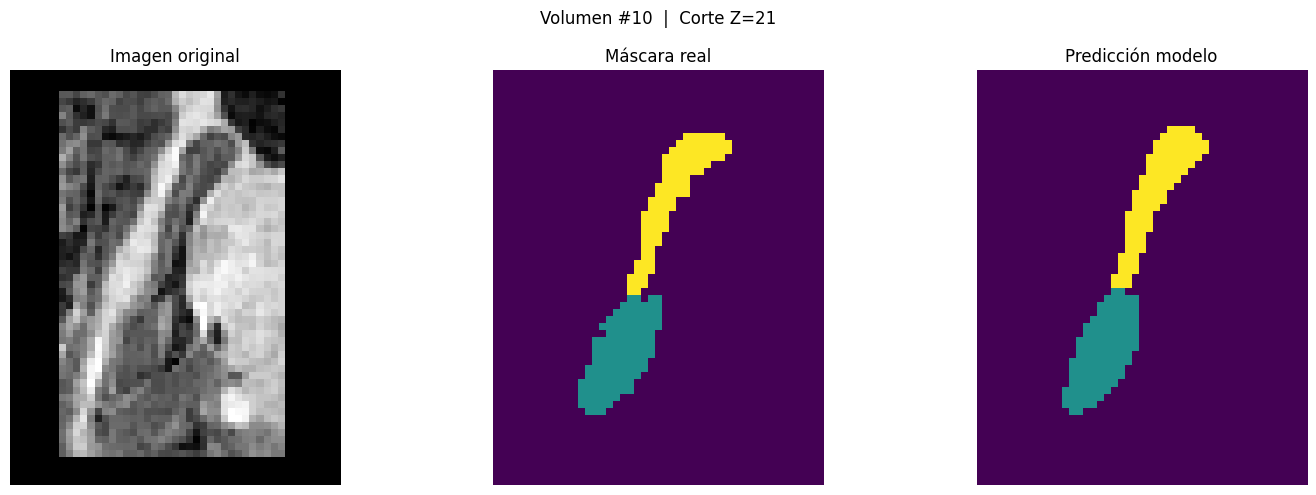

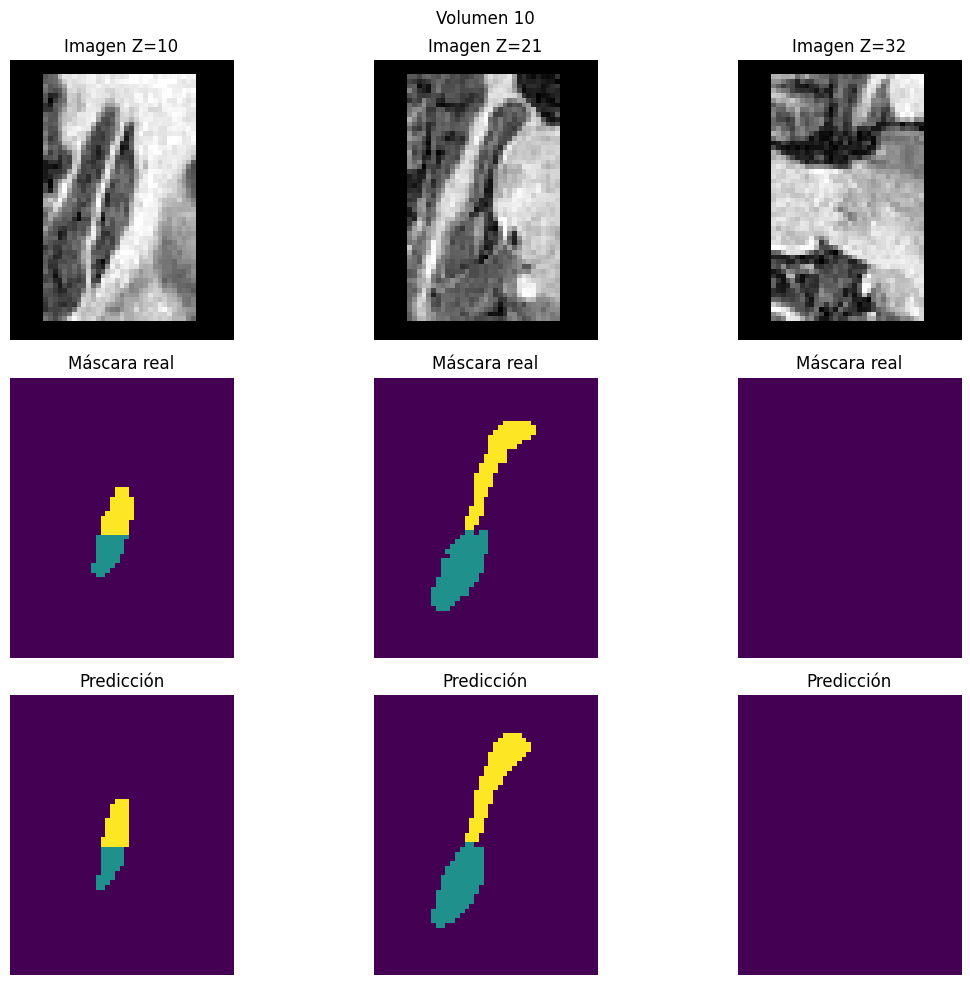

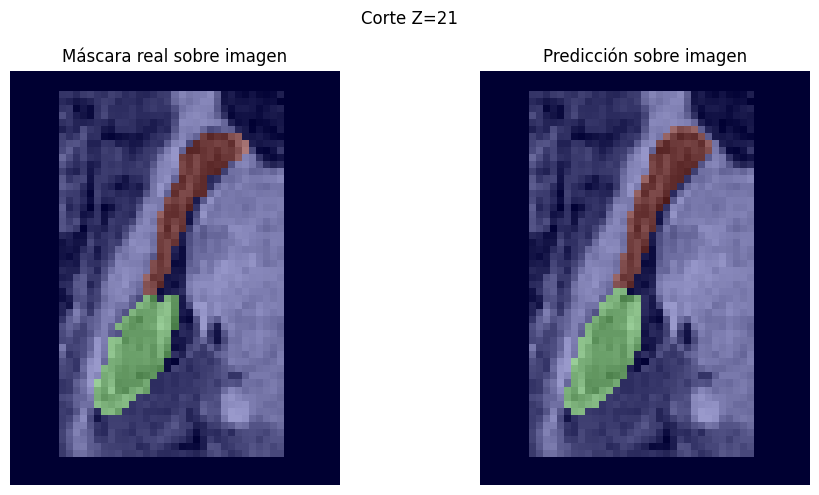

In [48]:
qualitative_eval(model, val_ds, device, num_classes=3, idx=10)

El modelo logra una segmentación tridimensional precisa del hipocampo, reproduciendo de forma muy cercana la forma y extensión de las estructuras reales. En los cortes mostrados, las regiones segmentadas por la red coinciden casi completamente con las máscaras reales, capturando tanto la zona principal como la prolongación superior. La coincidencia entre la predicción y la referencia visual confirma que la U-Net 3D aprendió adecuadamente la morfología del hipocampo, sin pérdidas notables de detalle ni errores de contorno significativos.


# **Créditos**
---

* **Profesor:** [Fabio Augusto Gonzalez](https://dis.unal.edu.co/~fgonza/)
* **Asistentes docentes :**
  * [Santiago Toledo Cortés](https://sites.google.com/unal.edu.co/santiagotoledo-cortes/)
* **Diseño de imágenes:**
    - [Mario Andres Rodriguez Triana](mailto:mrodrigueztr@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*